# Spiking Autoencoder for MNIST Reconstruction

## Overview
This notebook implements a spiking autoencoder using Spiking Neural Networks (SNNs) to reconstruct MNIST digit images from spike-based representations.

## Objectives
- Encode static images into spike trains using rate-based encoding
- Learn a mapping from spike inputs to reconstructed outputs
- Evaluate whether temporal spike activity can preserve image information

## Method Summary
Input images are converted into spike trains using rate coding. The spiking autoencoder processes these spike sequences over multiple timesteps, and the final reconstruction is obtained by averaging spike outputs across time.

## Scope
This is a proof-of-concept implementation focused on validating reconstruction capability using spike-based computation.

## Environment Setup

This section imports the required libraries for model implementation, dataset handling, and visualization.

In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from snntorch import spikegen
import matplotlib.pyplot as plt

from core.models import SpikingAutoencoder

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


## Data Preparation

The MNIST dataset is used as input for the reconstruction task. Images are converted to tensors and later flattened into vector form before spike encoding.

In [3]:
# Load MNIST dataset

transform = transforms.ToTensor()

train_ds = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False)

print("Training samples:", len(train_ds))


Training samples: 60000


## Spiking Autoencoder Model

The `SpikingAutoencoder` is a feedforward spiking neural network for image reconstruction.

- A linear encoder and decoder are used with LIF neurons  
- Input spike trains are processed over multiple timesteps  
- Reconstruction is obtained by averaging spike outputs over time  

The model is trained using mean squared error (MSE) between reconstructed and original inputs.

In [4]:
# Create the spiking autoencoder

model = SpikingAutoencoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

num_steps = 25   # number of spike simulation steps
epochs = 5


## Training Procedure

The model is trained to reconstruct input images from spike-based representations.

### Steps:
1. Flatten input images into vectors
2. Convert inputs into spike trains using rate encoding
3. Process spike sequences through the spiking autoencoder
4. Aggregate spike outputs across time to obtain reconstruction
5. Compute reconstruction loss and update model parameters

In [5]:
# Train the spiking autoencoder

loss_history = []

for epoch in range(epochs):
    total_loss = 0
    
    for x, _ in train_loader:
        # Flatten image: (B, 1, 28, 28) -> (B, 784)
        x = x.view(-1, 784).to(device)

        # Convert image to spike trains using Poisson rate coding
        spk_in = spikegen.rate(x, num_steps=num_steps)

        # Forward pass through spiking network
        spk_out = model(spk_in)

        # Reconstruct by averaging spikes over time
        recon = spk_out.mean(0)

        # Reconstruction loss
        loss = loss_fn(recon, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss = {avg_loss:.4f}")


Epoch 1, Loss = 0.0147
Epoch 2, Loss = 0.0039
Epoch 3, Loss = 0.0028
Epoch 4, Loss = 0.0023
Epoch 5, Loss = 0.0020


## Training Dynamics

The following plot shows the reconstruction loss across epochs, indicating how the model improves its ability to recover input images from spike activity.

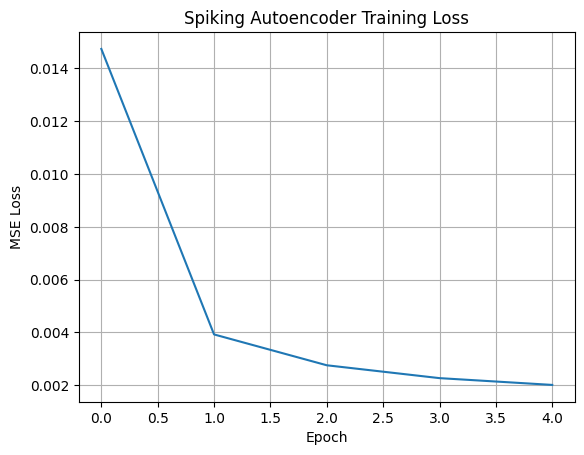

In [6]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Spiking Autoencoder Training Loss")
plt.grid(True)
plt.show()


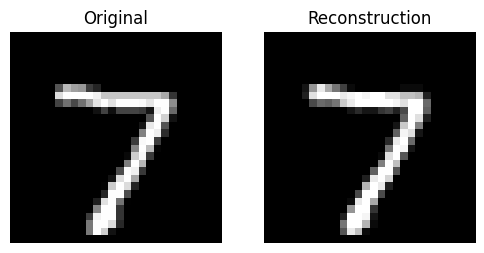

In [7]:
# Visualize original vs reconstructed image

model.eval()
with torch.no_grad():
    x, _ = next(iter(test_loader))
    x = x.view(-1, 784).to(device)

    spk = spikegen.rate(x, num_steps=num_steps)
    spk_out = model(spk)
    recon = spk_out.mean(0)

# Plot one example
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.imshow(x[0].cpu().view(28,28), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(recon[0].cpu().view(28,28), cmap="gray")
plt.title("Reconstruction")
plt.axis("off")

plt.show()


## Quantitative Evaluation

Reconstruction performance is evaluated using mean squared error (MSE) between the original and reconstructed images.

In [8]:
# Compute reconstruction error
mse = torch.mean((recon - x)**2)
print("Reconstruction MSE:", mse.item())

Reconstruction MSE: 0.0018767680739983916


## Conclusion

This notebook demonstrates that a spiking neural network can reconstruct MNIST images from spike-based inputs using rate encoding.

### Observations
- Rate encoding enables conversion of static images into spike trains suitable for spiking neural processing
- Aggregating spike activity over time produces a stable reconstruction of the input signal
- The model achieves low reconstruction error, indicating successful learning of the input–output mapping

### Quantitative Result
The reconstruction performance, measured using mean squared error (MSE), is:

**MSE: 0.00188**

### Interpretation
The results indicate that spike-based representations can preserve sufficient information for reconstruction when processed over multiple timesteps.

### Limitations
- The model uses a simple architecture without explicit latent constraints
- Reconstruction relies on rate-based encoding, which does not capture precise spike timing
- Evaluation is limited to a simple dataset and short training duration

### Takeaway
This experiment provides a proof-of-concept that spiking neural networks can perform reconstruction tasks using spike-based representations.